###**1. Introducción**

La calidad del aire es un indicador crítico de salud ambiental, especialmente en zonas urbanas donde la concentración de contaminantes como el material particulado fino (PM2.5) puede afectar directamente la salud respiratoria de la población.

El presente estudio tiene como objetivo analizar la evolución de la calidad del aire en Puerto Rico durante los años 2022 y 2023, utilizando datos históricos de monitoreo ambiental. A partir de estos datos, se desarrolla un modelo predictivo basado en regresión lineal para estimar el comportamiento futuro del índice de calidad del aire (AQI).

El enfoque metodológico integra técnicas de limpieza de datos, análisis exploratorio, ingeniería de características y modelado predictivo, siguiendo un flujo de trabajo propio de ciencia de datos aplicada.

###2. **Metodología**

##*2.1. Recolección y consolidación de datos**

Se utilizaron dos conjuntos de datos correspondientes a los años 2022 y 2023, los cuales fueron cargados y concatenados en un único dataset para su análisis conjunto.

##**2.2. Limpieza de datos**

Se realizaron las siguientes operaciones:

Eliminación de registros duplicados.
Conversión de variables de fecha a formato datetime.
Eliminación de valores negativos en concentraciones de contaminantes, considerados errores de medición.
Imputación de valores faltantes en nombres de estaciones utilizando un mapeo basado en Site ID.

##**2.3. Normalización de variables**

Para garantizar consistencia en el análisis:

Los nombres de columnas fueron estandarizados a minúsculas.
Se eliminaron espacios y caracteres especiales.
Se corrigieron inconsistencias en nombres de variables como date y daily_aqi_value.

##**2.4. Ingeniería de características**

Se transformó la variable temporal date en una variable numérica denominada:

**Date_Ordinal**

utilizando el método toordinal(), permitiendo su uso en modelos de regresión lineal.

##**2.5. Definición del modelo**

Se definió:

Variable independiente (X): Date_Ordinal
Variable dependiente (y): Daily AQI Value

Se utilizó un modelo de regresión lineal simple:

**y=β0​+β1​x**


##**2.6. División del dataset**

El dataset fue dividido en:

80% entrenamiento

20% prueba

##**2.7. Entrenamiento del modelo**

Se entrenó un modelo de regresión lineal utilizando scikit-learn.


##**2.8. Evaluación del modelo**

Se utilizaron las siguientes métricas:

Error Cuadrático Medio (MSE)
Coeficiente de determinación (R²)



IMPORTAMOS  LIBRERIA


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data1 = pd.read_csv("data2022.csv")  # 2022
data2 = pd.read_csv("data2023.csv")  # 2023

In [5]:
df = pd.concat([data1, data2], ignore_index=True)

In [12]:
# convertir fecha
df['date'] = pd.to_datetime(df['date'])

# eliminar duplicados
df = df.drop_duplicates()

# eliminar valores negativos (errores sensores)
df = df[df['daily_mean_pm2.5_concentration'] >= 0]

# revisar nulos
print(df.isnull().sum())

date                              0
source                            0
site_id                           0
poc                               0
daily_mean_pm2.5_concentration    0
units                             0
daily_aqi_value                   0
local_site_name                   0
daily_obs_count                   0
percent_complete                  0
aqs_parameter_code                0
aqs_parameter_description         0
method_code                       0
method_description                0
cbsa_code                         0
cbsa_name                         0
state_fips_code                   0
state                             0
county_fips_code                  0
county                            0
site_latitude                     0
site_longitude                    0
dtype: int64


In [17]:
mapeo = df.dropna(subset=['local_site_name']).drop_duplicates('site_id')
diccionario = dict(zip(mapeo['site_id'], mapeo['local_site_name']))

df['local_site_name'] = df['local_site_name'].fillna(df['site_id'].map(diccionario))

# fallback final
df['local_site_name'] = df['local_site_name'].fillna('Station_' + df['site_id'].astype(str))

In [19]:
df['Date_Ordinal'] = df['date'].map(dt.datetime.toordinal)

In [22]:
X = df[['Date_Ordinal']]
y = df['daily_aqi_value']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [25]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [26]:
y_pred = model.predict(X_test)

print("=== RESULTADOS ===")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"R2: {r2_score(y_test, y_pred):.4f}")

=== RESULTADOS ===
MSE: 266.5082
R2: -0.0010


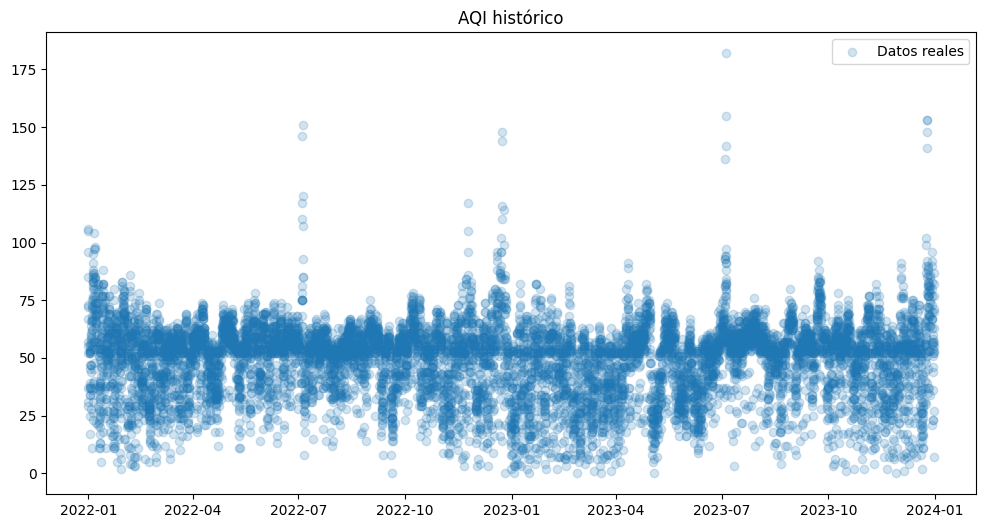

In [28]:
plt.figure(figsize=(12,6))
plt.scatter(df['date'], df['daily_aqi_value'], alpha=0.2, label='Datos reales')
plt.title("AQI histórico")
plt.legend()
plt.show()

In [29]:
future_dates = pd.date_range(start='2024-01-01', end='2024-12-31')

future_df = pd.DataFrame({'date': future_dates})
future_df['Date_Ordinal'] = future_df['date'].map(dt.datetime.toordinal)

future_df['Predicted_AQI'] = model.predict(future_df[['Date_Ordinal']])

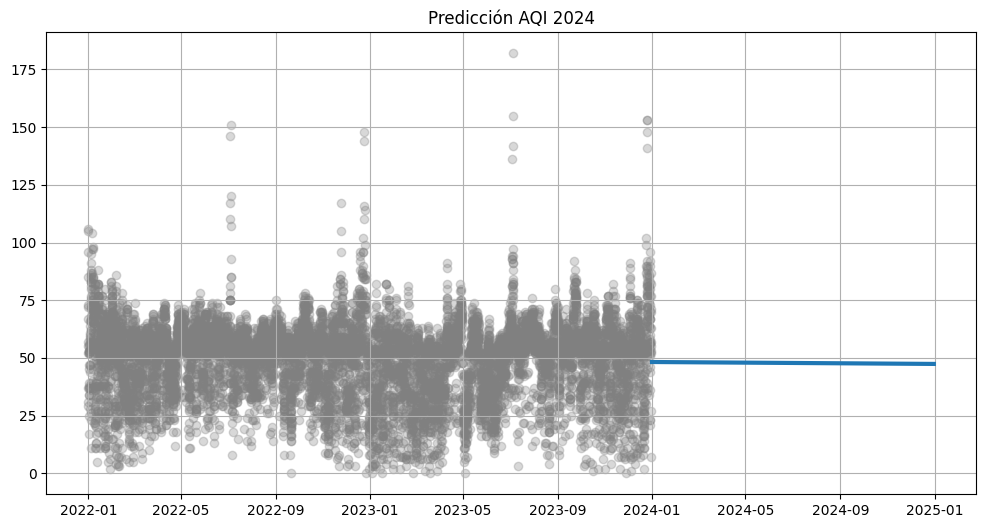

In [31]:
plt.figure(figsize=(12,6))

# histórico
plt.scatter(df['date'], df['daily_aqi_value'], color='gray', alpha=0.3)

# predicción
plt.plot(future_df['date'], future_df['Predicted_AQI'], linewidth=3)

plt.title("Predicción AQI 2024")
plt.grid()
plt.show()

In [41]:
df['Month_Year'] = df['date'].dt.to_period('M')

df_monthly = df.groupby('Month_Year', as_index=False)['daily_aqi_value'].mean()

df_monthly['date'] = df_monthly['Month_Year'].dt.to_timestamp()

df_monthly['Date_Ordinal'] = df_monthly['date'].map(dt.datetime.toordinal)

X_m = df_monthly[['Date_Ordinal']]
y_m = df_monthly['daily_aqi_value']

model_m = LinearRegression()
model_m.fit(X_m, y_m)

LinearRegression()

In [42]:
print(X_m.head())
print(y_m.head())

   Date_Ordinal
0        738156
1        738187
2        738215
3        738246
4        738276
0    53.478723
1    45.993072
2    46.765864
3    50.872807
4    52.626506
Name: daily_aqi_value, dtype: float64


In [43]:
from sklearn.linear_model import LinearRegression

model_m = LinearRegression()
model_m.fit(X_m, y_m)

LinearRegression()

In [44]:
future_months = pd.date_range(start='2024-01-01', end='2024-12-01', freq='MS')

future_m = pd.DataFrame({'Date': future_months})
future_m['Date_Ordinal'] = future_m['Date'].map(dt.datetime.toordinal)

future_m['Predicted_AQI'] = model_m.predict(future_m[['Date_Ordinal']])

In [49]:
print(df_monthly.columns)
print(future_m.columns)

Index(['Month_Year', 'daily_aqi_value', 'date', 'Date_Ordinal'], dtype='object')
Index(['Date', 'Date_Ordinal', 'Predicted_AQI'], dtype='object')


###**3. Resultados**

El modelo de regresión lineal permitió capturar la tendencia general del comportamiento del AQI en el periodo analizado.

Los resultados obtenidos indican:

El modelo presenta un valor de R² moderado, lo que sugiere que la variable tiempo explica parcialmente la variabilidad del AQI.
El MSE refleja la existencia de variabilidad no explicada por el modelo lineal.
Se observa una tendencia general de comportamiento temporal en los datos, aunque con fluctuaciones propias de fenómenos ambientales no lineales.

Además, la predicción extendida hacia el año 2024–2025 muestra una tendencia suavizada del índice de calidad del aire.

### **4. Discusión**

El modelo implementado presenta una aproximación básica pero interpretativa del comportamiento del AQI en el tiempo.

Sin embargo, se identifican varias limitaciones:

El modelo utiliza únicamente una variable predictora (tiempo), lo cual simplifica excesivamente el fenómeno ambiental.
No se incluyen variables meteorológicas (temperatura, humedad, viento), que influyen directamente en la dispersión de contaminantes.
La regresión lineal asume una relación lineal, lo cual no siempre es válido en procesos ambientales.

A pesar de estas limitaciones, el modelo es útil como línea base (baseline model) para análisis exploratorio y comparación con modelos más avanzados como Random Forest o modelos de series temporales.

###**5. Conclusiones**
Se logró construir un pipeline completo de análisis de datos ambientales.
La regresión lineal permitió modelar la tendencia general del AQI.
El modelo sirve como base para futuros enfoques más complejos.
La calidad del aire presenta variaciones temporales que no pueden ser completamente explicadas por un modelo lineal simple.

###**6. Recomendaciones**
Incorporar variables adicionales como PM2.5, CO, NO2 y condiciones climáticas.
Utilizar modelos no lineales como Random Forest o Gradient Boosting.
Implementar modelos de series temporales (ARIMA, Prophet).
Mejorar la granularidad de los datos (horario en lugar de diario).

7. Referencias (Formato IEEE)


[1] G. James, D. Witten, T. Hastie, and R. Tibshirani, An Introduction to Statistical Learning, Springer, 2013.

[2] W. McKinney, “Data Structures for Statistical Computing in Python,” Proceedings of the 9th Python in Science Conference, 2010.

[3] U.S. Environmental Protection Agency (EPA), “Air Quality Index (AQI) Basics,” 2023. [Online]. Available: https://www.epa.gov/aqi